In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
df = pd.read_csv('C:\\Users\\Administrator\\Desktop\\spam_message_classifier\\data\\spam.csv', encoding='latin1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Dataset understanding and Basic cleaning

In [7]:
# useful cols / rename cols
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.shape

(5572, 2)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [10]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [11]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
# Remove duplicates

df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("Dataset after removing duplicate vals:", df.shape)

Dataset after removing duplicate vals: (5169, 2)


In [14]:
# Check spam vs ham
df["label"].value_counts()  # Dataset is imbalanced: there are many more legitimate messages than spam messages.

label
ham     4516
spam     653
Name: count, dtype: int64

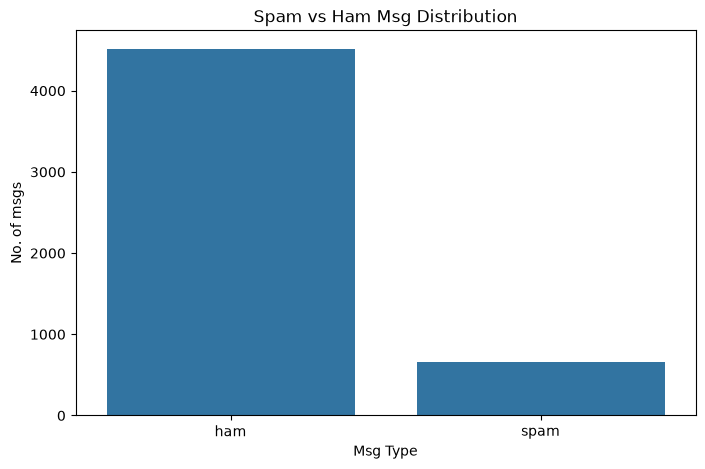

In [15]:
# Vistualize
plt.figure(figsize=(8,5))
sns.countplot(
    data = df,
    x = 'label'
)

plt.xlabel("Msg Type")
plt.ylabel("No. of msgs")
plt.title("Spam vs Ham Msg Distribution")

plt.show()

In [16]:
# Convert labels into numbers
df['label'] = df['label'].map({
    'spam': 1,
    'ham': 0
})

In [17]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [18]:
# Check the cleaned dataset

print("Total mgs:", len(df))
print("Total Ham msg:", (df['label'] == 0).sum())
print("Total Spam msg:", (df['label'] == 1).sum())

Total mgs: 5169
Total Ham msg: 4516
Total Spam msg: 653


In [19]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Text Preprocessing - NLP

In [20]:
# Look at raw messages first

for i in range(5):
    print("Message:", df["message"].iloc[i])
    print("-" * 80)

Message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
--------------------------------------------------------------------------------
Message: Ok lar... Joking wif u oni...
--------------------------------------------------------------------------------
Message: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
--------------------------------------------------------------------------------
Message: U dun say so early hor... U c already then say...
--------------------------------------------------------------------------------
Message: Nah I don't think he goes to usf, he lives around here though
--------------------------------------------------------------------------------


In [21]:
def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [22]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
# Checking for 1 msg or testing the fnx

test_msg = "WIN £500!!! Visit https://example.com NOW!"
print("Original:")
print(test_msg)

print("\nCleaned:")
print(clean_text(test_msg))



Original:
WIN £500!!! Visit https://example.com NOW!

Cleaned:
win £ visit now


In [24]:
# Apply cleaning to the entire dataset

df["clean_message"] = df["message"].apply(clean_text)

In [25]:
df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [26]:
# Compare original vs cleaned messages

for i in range(10):

    print("ORIGINAL:")
    print(df["message"].iloc[i])

    print("\nCLEANED:")
    print(df["clean_message"].iloc[i])

    print("=" * 100)

ORIGINAL:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

CLEANED:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
ORIGINAL:
Ok lar... Joking wif u oni...

CLEANED:
ok lar joking wif u oni
ORIGINAL:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

CLEANED:
free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs
ORIGINAL:
U dun say so early hor... U c already then say...

CLEANED:
u dun say so early hor u c already then say
ORIGINAL:
Nah I don't think he goes to usf, he lives around here though

CLEANED:
nah i dont think he goes to usf he lives around here though
ORIGINAL:
FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs t

In [27]:
# Check for empty messages

empty_messages = df["clean_message"].str.strip().eq("").sum()

print("Empty messages:", empty_messages)

Empty messages: 3


In [28]:
df = df[df["clean_message"].str.strip() != ""]

df = df.reset_index(drop=True)

In [29]:
# Compare message lengths - feature engineering.

df["message_length"] = df["message"].str.len()

df["word_count"] = df["message"].str.split().str.len()

In [30]:
df.head()

,label,message,clean_message,message_length,word_count
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,111,20
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,155,28
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,61,13


In [31]:
# Compare spam and ham message lengths - exploratory data analysis + feature engineering

df.groupby("label")[["message_length", "word_count"]].mean()



,message_length,word_count
label,,
0,70.503213,14.143142
1,137.891271,23.681470


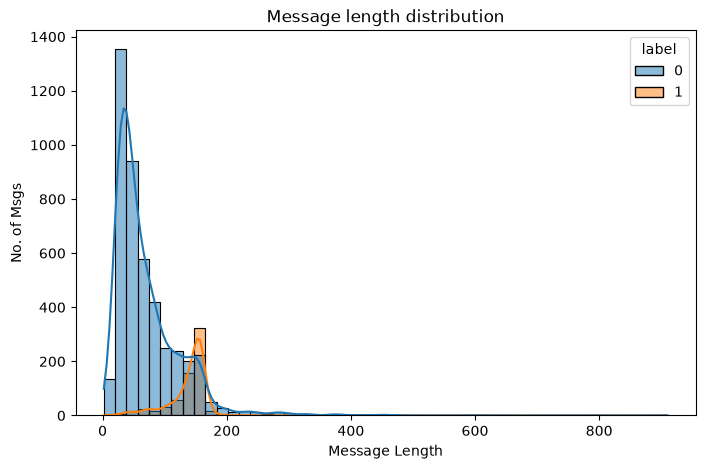

In [32]:
# Visualize message length

plt.figure(figsize=(8,5))

sns.histplot(
    data = df,
    x = "message_length",
    hue = "label",
    bins = 50,
    kde = True
)

plt.xlabel("Message Length")
plt.ylabel("No. of Msgs")
plt.title("Message length distribution")

plt.show()


In [33]:
# Check the final dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 5166
Columns: 5


,label,message,clean_message,message_length,word_count
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,111,20
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,155,28
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,61,13


Train/Test Split + TF-IDF

In [34]:
# Select input and target

X = df["clean_message"]
y = df["label"]

In [35]:
print(X.head())

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in a wkly comp to win fa cup final ...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: clean_message, dtype: str


In [36]:
print(y.head())

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [37]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# stratify => dataset is imbalanced:keeps approximately the same spam/ham proportion in both training and testing sets.

In [38]:
print("training messages:", len(X_train))

print("testing messages:", len(X_test))

training messages: 4132
testing messages: 1034


In [39]:
print("training class distribution:", y_train.value_counts())

print("testing class distribution:", y_test.value_counts())

training class distribution: label
0    3610
1     522
Name: count, dtype: int64
testing class distribution: label
0    903
1    131
Name: count, dtype: int64


In [40]:
# Create the TF-IDF vectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,  #Ignore words that occur in only one document
    sublinear_tf=True #word appears many times
)

In [41]:
# Fit TF-IDF ONLY on training data

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [42]:
print("Training TF-IDF shape:", X_train_tfidf.shape)

print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4132, 5000)
Testing TF-IDF shape: (1034, 5000)


In [43]:
# See the vocabulary

features_names = vectorizer.get_feature_names_out()

print("No. of features:", len(features_names))

print("\nFirst 50 features:", features_names[:50])

No. of features: 5000

First 50 features: ['abiola' 'able' 'able to' 'about' 'about how' 'about me' 'about smiling'
 'about that' 'about the' 'about this' 'about to' 'about you' 'about your'
 'abt' 'ac' 'accept' 'access' 'accidentally' 'account' 'account statement'
 'ache' 'ache to' 'across' 'across the' 'action' 'activate' 'actually'
 'ad' 'add' 'address' 'admirer' 'admirer who' 'adult' 'advance' 'advice'
 'afraid' 'aft' 'aft ur' 'after' 'after ltgt' 'after lunch' 'after that'
 'afternoon' 'afternoon my' 'aftr' 'again' 'against' 'age' 'ages' 'ago']


In [44]:
# pharse
features = vectorizer.get_feature_names_out()

for feature in features:
    if "free" in feature:
        print(feature)


all free
be free
call free
call freephone
for free
free
free auction
free bluetooth
free call
free camcorder
free entry
free for
free from
free minutes
free msg
free now
free on
free text
free texts
free to
freefone
freemsg
freephone
freephone now
get free
im free
is free
mobile free
nokia free
our free
phones free
plus free
send free
text free
texts free
tone free
vouchers free
with free
you free
your free


In [45]:
# Understand one message's TF-IDF representation

print("Original message:")
print(X_train.iloc[0])

print("\nTF-IDF vector shape:")
print(X_train_tfidf[0].shape)

Original message:
today iz yellow rose day if u love my frndship give me misscall amp send this to ur frndz amp see how many miss calls u get if u get missed u marry ur lover

TF-IDF vector shape:
(1, 5000)


In [46]:
# Check how sparse the matrix is

print("TF-IDF matrix type:")
print(type(X_train_tfidf))

print("\nNon-zero values:")
print(X_train_tfidf.nnz)

print("\nTotal possible values:")
print(
    X_train_tfidf.shape[0] *
    X_train_tfidf.shape[1]
)

print("TF-IDF vectorization completed successfully!")

TF-IDF matrix type:
<class 'scipy.sparse._csr.csr_matrix'>

Non-zero values:
63892

Total possible values:
20660000
TF-IDF vectorization completed successfully!


Train 3 Classification Models

A] Model 1 — Multinomial Naive Bayes

In [47]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3610., 522.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.14,-2.07]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[2.34,5.28,4.86,...,0.85,1.44,2.1 ], [0. ,0. ,0. ,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-8.54,-7.91,-7.98,...,-9.14,-8.86,-8.62], [-8.92,-8.92,-8.92,...,-8.92,-8.92,-8.92]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


In [48]:
nb_pred = nb_model.predict(X_test_tfidf)

In [49]:
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9700193423597679


B] Model 2 — Logistic Regression

In [50]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [51]:
lr_pred = lr_model.predict(X_test_tfidf)

In [52]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.965183752417795


C] Model 3 — Linear SVM

In [53]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [54]:
svm_pred = svm_model.predict(X_test_tfidf)

In [55]:
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.9835589941972921


Compare the three models

In [56]:
model_comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "Accuracy": [nb_accuracy, lr_accuracy, svm_accuracy]
})

model_comparison

,Model,Accuracy
0,Naive Bayes,0.970019
1,Logistic Regression,0.965184
2,Linear SVM,0.983559


In [57]:
# Calculate Precision, Recall and F1

def evaulate_model(name, y_true, y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)

  return{
      "Model": name,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "F1 Score": f1
  }

In [58]:
results = []

results.append(evaulate_model("Multinominal Naive Bayes", y_test, nb_pred))
results.append(evaulate_model("Logistic Regression", y_test, lr_pred))
results.append(evaulate_model("Linear SVM", y_test, svm_pred))

In [59]:
results_df  = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinominal Naive Bayes,0.970019,1.000000,0.763359,0.865801
1,Logistic Regression,0.965184,0.979798,0.740458,0.843478
2,Linear SVM,0.983559,0.975000,0.893130,0.932271


In [60]:
results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinominal Naive Bayes,0.9700,1.0000,0.7634,0.8658
1,Logistic Regression,0.9652,0.9798,0.7405,0.8435
2,Linear SVM,0.9836,0.9750,0.8931,0.9323


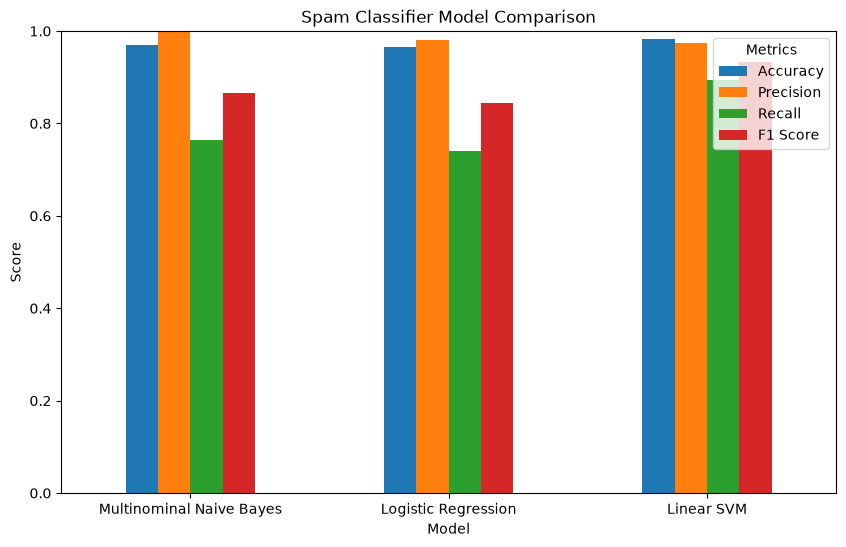

In [61]:
# Visualize model comparison

results_plot = results_df.set_index("Model")

results_plot[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(10,6),
)

plt.title("Spam Classifier Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metrics"
)

plt.show()

Classification Reports

In [62]:
print("Naive Bayes Classification Report:")
print(classification_report(y_test, nb_pred, target_names=["Ham", "Spam"]))

print("\n Logistic Regression Classification Report:")
print(classification_report(y_test, lr_pred, target_names=["Ham", "Spam"]))

print("\nLinear SVM Classification Report:")
print(classification_report(y_test, svm_pred, target_names=["Ham", "Spam"]))

Naive Bayes Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.76      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034


 Logistic Regression Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.98      0.74      0.84       131

    accuracy                           0.97      1034
   macro avg       0.97      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034


Linear SVM Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg 

Confusion Matrix

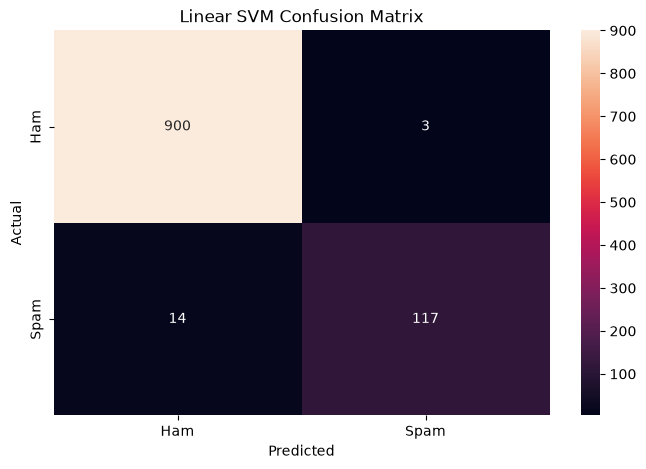

In [63]:
# Confusion Matrix - Linear SVM Model

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM Confusion Matrix")

plt.show()

ROC-AUC, ROC Curve & Prediction Probability

1] Get prediction scores

In [64]:
nb_probability = nb_model.predict_proba(X_test_tfidf)[:,1]
lr_probability = lr_model.predict_proba(X_test_tfidf)[:,1]
svm_scores = svm_model.decision_function(X_test_tfidf)

In [65]:
# Calculate ROC-AUC

nb_auc = roc_auc_score(y_test, nb_probability)
lr_auc = roc_auc_score(y_test, lr_probability)
svm_auc = roc_auc_score(y_test, svm_scores)

print("Naive Bayes ROC-AUC",nb_auc)
print("Logistic Regression ROC-AUC", lr_auc)
print("Linear SVM ROC-AUC", svm_auc)

Naive Bayes ROC-AUC 0.9790351077409483
Logistic Regression ROC-AUC 0.9880550835636935
Linear SVM ROC-AUC 0.9924509480696238


In [66]:
# Add ROC-AUC to our comparison table

results_df["ROC-AUC"] = [nb_auc, lr_auc, svm_auc]

results_df

# format it
results_df.style.format({
    "ROC-AUC": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "ROC-AUC": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Multinominal Naive Bayes,0.970019,1.0000,0.7634,0.8658,0.9790
1,Logistic Regression,0.965184,0.9798,0.7405,0.8435,0.9881
2,Linear SVM,0.983559,0.9750,0.8931,0.9323,0.9925


In [67]:
# Create the ROC curve
from sklearn.metrics import roc_curve

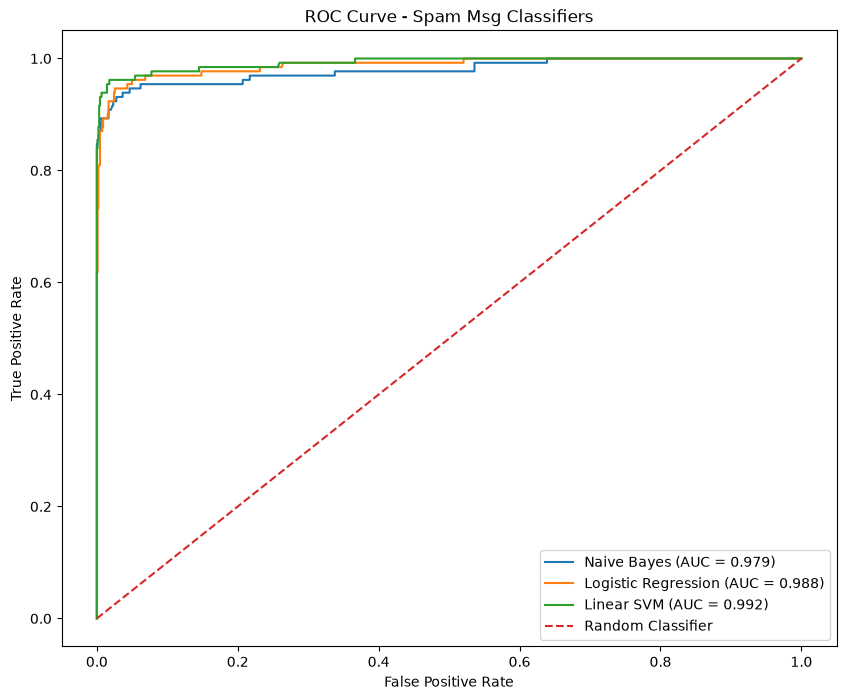

In [68]:
# Calc ROC curve for each model
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probability)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probability)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = {nb_auc:.3f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, label=f'Linear SVM (AUC = {svm_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle="--", label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Spam Msg Classifiers')

plt.legend()

plt.show()

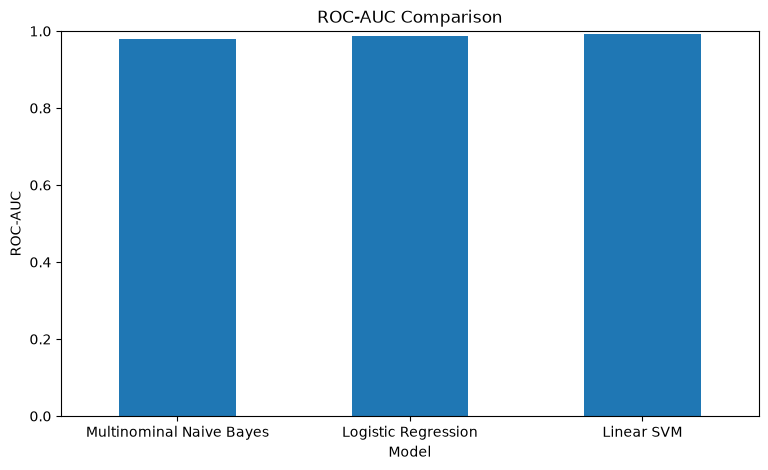

In [69]:
# Add ROC-AUC to model comparison

roc_plot = results_df.set_index("Model")["ROC-AUC"]

roc_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [70]:
final_comparison = results_df.copy()

final_comparison = final_comparison.round(4)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Multinominal Naive Bayes,0.9700,1.0000,0.7634,0.8658,0.9790
1,Logistic Regression,0.9652,0.9798,0.7405,0.8435,0.9881
2,Linear SVM,0.9836,0.9750,0.8931,0.9323,0.9925


Test probability on a new message - Create a completely new message:

In [71]:
new_message = ["Congratulations! You have won a free cash prize. Click here to claim now!"]

# clean
new_message_clean = [
    clean_text(message)
    for message in new_message
]

# Convert into fitted TF-IDF vectorizer
new_message_tfidf = vectorizer.transform(new_message_clean)

# Logistic Regression to get probabilities
probabilities = lr_model.predict_proba(new_message_tfidf)

# Calculate and print percentages directly
ham_percentage = probabilities[0][0] * 100
spam_percentage = probabilities[0][1] * 100

print(f"Ham Percentage (%): {ham_percentage:.2f}")
print(f"Spam Percentage (%): {spam_percentage:.2f}")

Ham Percentage (%): 7.10
Spam Percentage (%): 92.90


In [72]:
# Test a normal message
new_message = ["Hey, are you coming to college tomorrow?"]

new_message_clean = [
    clean_text(message)
    for message in new_message
]

new_message_tfidf = vectorizer.transform(new_message_clean)

probabilities = lr_model.predict_proba(new_message_tfidf)

ham_probability = probabilities[0][0]
spam_probability = probabilities[0][1]

print(f"Ham Probability: {ham_probability * 100:.2f}%")

print(f"Spam Probability: {spam_probability * 100:.2f}%")

Ham Probability: 95.95%
Spam Probability: 4.05%


In [73]:
# Create a reusable prediction function - for streamlit application
def predict_message(message):

    # Clean message
    cleaned_message = clean_text(message)

    # Convert text to TF-IDF
    message_tfidf = vectorizer.transform([cleaned_message])

    # Get probabilities
    probabilities = lr_model.predict_proba(message_tfidf)[0]

    ham_probability = probabilities[0]
    spam_probability = probabilities[1]

    # Determine class
    if spam_probability >= 0.5:
        prediction = "SPAM"
    else:
        prediction = "HAM"

    return (
        prediction,
        ham_probability,
        spam_probability
    )

In [74]:
prediction, ham_prob, spam_prob = predict_message(
     "Congratulations! You won a free prize. Claim now!"
)

print("Prediction:", prediction)
print(f"Ham: {ham_prob * 100:.2f}%")
print(f"Spam: {spam_prob * 100:.2f}%")

Prediction: SPAM
Ham: 18.32%
Spam: 81.68%


Error Analysis

In [75]:
# Create a results DataFrame

error_analysis = pd.DataFrame({
    "message" : X_test.values,
    "actual" : y_test.values,
    "predicted": lr_pred
})
error_analysis.head()  # ham => 0 and spam => 1

,message,actual,predicted
0,was doing my test earlier i appreciate you wil...,0,0
1,im still pretty weak today bad day,0,0
2,im used to it i just hope my agents dont drop ...,0,0
3,designation is software developer and may be s...,0,0
4,omg if its not one thing its another my cat ha...,0,0


In [76]:
# Find incorrect predictions

errors = error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
]

print("Total incorrect predictions:", len(errors))

Total incorrect predictions: 36


In [77]:
errors.head(10)

,message,actual,predicted
16,waiting for your call,0,1
102,check out choose your babe videos smsshsexnetu...,1,0
105,bought one ringtone and now getting texts cost...,1,0
112,hi babe its jordan how r u im home from abroad...,1,0
125,send a logo ur lover names joined by a heart t...,1,0
151,wow the boys r back take that uk tour win vip ...,1,0
174,you will recieve your tone within the next hrs...,1,0
208,as a registered optin subscriber ur draw å£ gi...,1,0
241,babe u want me dont u baby im nasty and have a...,1,0
249,rtking pro video club need help or call you mu...,1,0


1] False Positives

In [78]:
# Actual: HAM & Predicted: SPAM => legitimate message was incorrectly marked as spam.

false_positives = errors[
    (errors["actual"] == 0) & (errors["predicted"] == 1)
]

print("False Positives:", len(false_positives))
false_positives.head(20)

False Positives: 2


,message,actual,predicted
16,waiting for your call,0,1
920,i career tel have added u as a contact on indy...,0,1


2] False Negatives

In [79]:
# Actual: SPAM & Predicted: HAM => model has missed actual spam

false_negatives = error_analysis[
    (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

false_negatives.head(20)

False Negatives: 34


,message,actual,predicted
102,check out choose your babe videos smsshsexnetu...,1,0
105,bought one ringtone and now getting texts cost...,1,0
112,hi babe its jordan how r u im home from abroad...,1,0
125,send a logo ur lover names joined by a heart t...,1,0
151,wow the boys r back take that uk tour win vip ...,1,0
174,you will recieve your tone within the next hrs...,1,0
208,as a registered optin subscriber ur draw å£ gi...,1,0
241,babe u want me dont u baby im nasty and have a...,1,0
249,rtking pro video club need help or call you mu...,1,0
255,freemsg hey u i just got of these videopic fon...,1,0


In [80]:
# Display the mistakes clearly => gives actual examples of model errors

print("false positives ====>")
print("=" * 80)

for message in false_positives["message"].head(10):
  print(message)
  print("=" * 80)

print("false negatives =====>")
print("=" * 80)

for message in false_negatives["message"].head(10):
  print(message)
  print("=" * 80)

false positives ====>
waiting for your call
i career tel have added u as a contact on indyarockscom to send free sms to remove from phonebook sms no to ltgt
false negatives =====>
check out choose your babe videos smsshsexnetun fgkslpopw fgkslpo
bought one ringtone and now getting texts costing pound offering more tones etc
hi babe its jordan how r u im home from abroad and lonely text me back if u wanna chat xxsp visionsmscom text stop to stopcost p
send a logo ur lover names joined by a heart txt love name name mobno eg love adam eve to yahoo poboxwwq txtno no ads p
wow the boys r back take that uk tour win vip tickets prebook with vip club txt club to trackmarque ltd
you will recieve your tone within the next hrs for terms and conditions please see channel u teletext pg
as a registered optin subscriber ur draw å£ gift voucher will be entered on receipt of a correct ans to whats no in the bbc charts
babe u want me dont u baby im nasty and have a thing filthyguys fancy a rude time wit

In [81]:
# Count the different types of errors

error_summary = pd.DataFrame({
    "Error Type": ["False Positives", "False Negatives"],
    "Count": [len(false_positives), len(false_negatives)]
})

error_summary

,Error Type,Count
0,False Positives,2
1,False Negatives,34


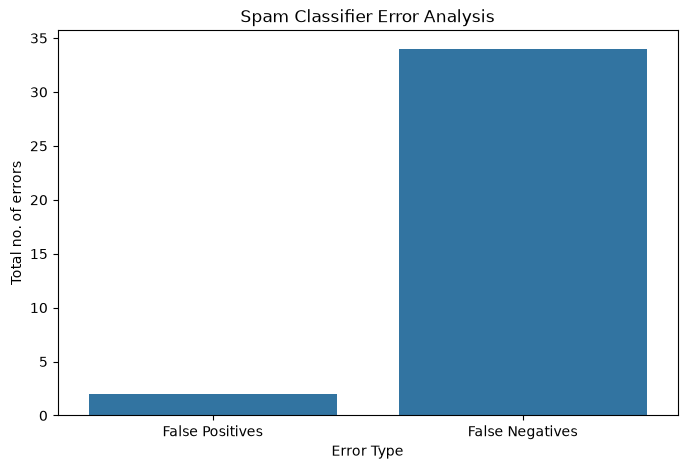

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data= error_summary,
    x="Error Type",
    y="Count"
)

plt.xlabel("Error Type")
plt.ylabel("Total no. of errors")
plt.title("Spam Classifier Error Analysis")

plt.show()

In [83]:
# most confident mistakes
test_probabilities = lr_model.predict_proba(X_test_tfidf)[:,1]

# Add them to DataFrame
error_analysis["spam_probability"] = test_probabilities

# inspect the incorrect predictions
error_analysis[
    error_analysis["actual"] != error_analysis["predicted"]
].sort_values(
    "spam_probability",
    ascending=False
).head(10)   #find messages where the model was very confident but still wrong

,message,actual,predicted,spam_probability
16,waiting for your call,0,1,0.608889
920,i career tel have added u as a contact on indy...,0,1,0.512956
263,u have a secret admirer who is looking make co...,1,0,0.494339
540,u have a secret admirer who is looking make co...,1,0,0.494339
151,wow the boys r back take that uk tour win vip ...,1,0,0.490463
700,sunshine quiz wkly q win a top sony dvd player...,1,0,0.479058
450,smsservices for yourinclusive text credits pls...,1,0,0.464165
639,customer service announcement we recently trie...,1,0,0.438832
509,important information orange user today is you...,1,0,0.432875
470,free msg sorry a service you ordered from coul...,1,0,0.414678


In [84]:
# 1] Examine suspicious false positives => fp with their probabilities

false_positives_with_prob = error_analysis[
    (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0)
].sort_values(
    "spam_probability",
    ascending=False
)

false_positives_with_prob[
    ["message", "spam_probability"]
].head(10)


,message,spam_probability
540,u have a secret admirer who is looking make co...,0.494339
263,u have a secret admirer who is looking make co...,0.494339
151,wow the boys r back take that uk tour win vip ...,0.490463
700,sunshine quiz wkly q win a top sony dvd player...,0.479058
450,smsservices for yourinclusive text credits pls...,0.464165
639,customer service announcement we recently trie...,0.438832
509,important information orange user today is you...,0.432875
470,free msg sorry a service you ordered from coul...,0.414678
699,guess what somebody you know secretly fancies ...,0.403454
899,camera you are awarded a sipix digital camera ...,0.386834


In [85]:
# 2] Examine difficult spam messages

false_negatives_with_prob = error_analysis[
    (error_analysis["actual"] == 1) &
    (error_analysis["predicted"] == 0)
].sort_values(
    "spam_probability",
    ascending=True
)

false_negatives_with_prob[
    ["message", "spam_probability"]
].head(10)

,message,spam_probability
553,hi its lucy hubby at meetins all day fri i wil...,0.044695
461,ringtoneking,0.065390
560,in the simpsons movie released in july name th...,0.069065
241,babe u want me dont u baby im nasty and have a...,0.083621
652,latest news police station toilet stolen cops ...,0.118814
926,sms ac sun posts helloyou seem cool,0.139200
326,datingi have had two of these only started aft...,0.146385
302,missed call alert these numbers called but lef...,0.168914
255,freemsg hey u i just got of these videopic fon...,0.171637
102,check out choose your babe videos smsshsexnetu...,0.172044


In [86]:
# Calc the error rate

error_rate = len(errors) / len(error_analysis)

print(f"Error Rate: {error_rate * 100:.2f}%")

Error Rate: 3.48%


In [87]:
accuracy = accuracy_score(y_test, lr_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 96.52%


In [88]:
# final evaluation report

final_metrics = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred),
    "ROC-AUC": roc_auc_score(y_test, lr_probability)
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df.style.format("{:.4f}")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.9652,0.9798,0.7405,0.8435,0.9881


In [91]:
final_metrics_df.to_csv(
"C:\\Users\\Administrator\\Desktop\\spam_message_classifier\\notebooks\\model_metrics.csv",
    index=False
)

results_df.to_csv(
    "C:\\Users\\Administrator\\Desktop\\spam_message_classifier\\notebooks\\model_comparison.csv",
    index=False
)



In [ ]:
joblib.dump(
    lr_model,
    "C:\\Users\\Administrator\\Desktop\\spam_message_classifier\\notebooks\\spam_classifier.pkl"
)

joblib.dump(
    vectorizer,
    "C:\\Users\\Administrator\\Desktop\\spam_message_classifier\\notebooks\\tfidf_vectorizer.pkl"
)

print("Model and vectorizer saved successfully!")

NameError: name 'joblib' is not defined